# PS3

## Problem 1

### (A)

<img src="photos/1a.jpg" width="400" />

### (B)


#### PINN for (A)

In [25]:
# Import TensorFlow and NumPy
import tensorflow as tf
import numpy as np
from pathlib import Path

# Set data type
DTYPE = "float32"
tf.keras.backend.set_floatx(DTYPE)

# Constants: EI = L = w = F = 1 (writeups use P for tip load; code uses F)
L = tf.constant(1.0, dtype=DTYPE)
F = tf.constant(1.0, dtype=DTYPE)  # tip force at x=L, scenario (A)
W = tf.constant(1.0, dtype=DTYPE)  # uniform load intensity w, scenarios (B) and (C)

# PDE: f'''' = Q_load  (set before training: 0 for A, W for B/C with EI=1)
Q_load = tf.Variable(0.0, trainable=False, dtype=DTYPE)


def make_model():
    return tf.keras.Sequential(
        [
            tf.keras.layers.Input(shape=(1,)),
            tf.keras.layers.Dense(64, activation="tanh"),
            tf.keras.layers.Dense(64, activation="tanh"),
            tf.keras.layers.Dense(64, activation="tanh"),
            tf.keras.layers.Dense(64, activation="tanh"),
            tf.keras.layers.Dense(1),
        ]
    )


model = make_model()


def f_and_derivs(x):
    """Return f, f', f'', f''', f'''' at x (eager: must stay eager because `model` is replaced each scenario)."""
    x = tf.convert_to_tensor(x)
    with tf.GradientTape(persistent=True) as t4:
        t4.watch(x)
        with tf.GradientTape(persistent=True) as t3:
            t3.watch(x)
            with tf.GradientTape(persistent=True) as t2:
                t2.watch(x)
                with tf.GradientTape() as t1:
                    t1.watch(x)
                    f = model(x)
                f_x = t1.gradient(f, x)
            f_xx = t2.gradient(f_x, x)
        f_xxx = t3.gradient(f_xx, x)
    f_xxxx = t4.gradient(f_xxx, x)
    del t2, t3, t4
    return f, f_x, f_xx, f_xxx, f_xxxx


def residual(x):
    _, _, _, _, f_xxxx = f_and_derivs(x)
    return f_xxxx - Q_load


def mean_square(tensor):
    return tf.reduce_mean(tf.square(tensor))


# Case (A): cantilever, tip load F at x=L (diagram P = F in code), q=0 in domain.
# Part (a) y = F/(6EI)(x^3 - 3Lx^2) gives EI y'''(L) = F at x=L (EI=1).
# If your grader insists on EI v'''(L) = -F from the figure, use shear_free + F instead.
def bc_terms_case_A():
    x_fixed = tf.zeros((1, 1), dtype=DTYPE)
    x_free = tf.ones((1, 1), dtype=DTYPE) * L
    f_fixed, slope_fixed, _, _, _ = f_and_derivs(x_fixed)
    _, _, moment_free, shear_free, _ = f_and_derivs(x_free)
    # Keys must not contain f''' inside "..." — TensorFlow AutoGraph misparses that as an f-string.
    return {
        "disp_0": f_fixed,
        "slope_0": slope_fixed,
        "moment_L": moment_free,
        "shear_L_minus_F": shear_free - F,
    }


# Case (B): cantilever, uniform load — f'''' = w; free end: M=V=0
def bc_terms_case_B():
    x_fixed = tf.zeros((1, 1), dtype=DTYPE)
    x_free = tf.ones((1, 1), dtype=DTYPE) * L
    f_fixed, slope_fixed, _, _, _ = f_and_derivs(x_fixed)
    _, _, moment_free, shear_free, _ = f_and_derivs(x_free)
    return {
        "disp_0": f_fixed,
        "slope_0": slope_fixed,
        "moment_L": moment_free,
        "shear_L": shear_free,
    }


# Case (C): simply supported, uniform load — f=M=0 at both ends
def bc_terms_case_C():
    x0 = tf.zeros((1, 1), dtype=DTYPE)
    xL = tf.ones((1, 1), dtype=DTYPE) * L
    f0, _, m0, _, _ = f_and_derivs(x0)
    fL, _, mL, _, _ = f_and_derivs(xL)
    return {
        "disp_0": f0,
        "disp_L": fL,
        "moment_0": m0,
        "moment_L": mL,
    }


def train_pinn(bc_terms_fn, num_steps=5000, print_every=200, lr=1e-3, N_col=200):
    """Collocation on (0, L); BC residuals from bc_terms_fn."""
    global model
    x_col = np.random.rand(N_col, 1).astype(np.float32) * float(L.numpy())
    x_col = tf.convert_to_tensor(x_col, dtype=DTYPE)
    optimizer = tf.keras.optimizers.Adam(lr)

    @tf.function
    def train_step(xc):
        with tf.GradientTape() as tape:
            r = residual(xc)
            loss_pde = mean_square(r)
            bc = bc_terms_fn()
            loss_bc = tf.constant(0.0, dtype=DTYPE)
            for name in bc:
                loss_bc = loss_bc + mean_square(bc[name])
            loss_total = loss_pde + loss_bc
        grads = tape.gradient(loss_total, model.trainable_variables)
        optimizer.apply_gradients(zip(grads, model.trainable_variables))
        return loss_total, loss_pde, loss_bc

    for step in range(num_steps):
        loss_total, loss_pde, loss_bc = train_step(x_col)
        if step % print_every == 0:
            print(
                "step:", step,
                "  total:", float(loss_total.numpy()),
                "  pde:", float(loss_pde.numpy()),
                "  bc:", float(loss_bc.numpy()),
            )


def local_homework_dir():
    for p in [Path(".").resolve()] + list(Path(".").resolve().parents):
        if (p / "PS3.ipynb").is_file():
            return p
    return Path(".").resolve()


def f_analytic_A(x):
    """Part (a): y = F/(6EI) (x^3 - 3 L x^2); with EI=L=F=1 this is x^3/6 - x^2/2."""
    x = np.asarray(x, dtype=np.float64)
    Lv, Fv = float(L.numpy()), float(F.numpy())
    return (Fv / 6.0) * (x ** 3 - 3.0 * Lv * x ** 2)


def f_analytic_B(x):
    """Part (a): y = (w x^2)/(24 EI) (6 L^2 - 4 L x + x^2); L=w=EI=1 matches homework red box."""
    x = np.asarray(x, dtype=np.float64)
    Lv, wv = float(L.numpy()), float(W.numpy())
    return (wv / 24.0) * x ** 2 * (6.0 * Lv ** 2 - 4.0 * Lv * x + x ** 2)


def f_analytic_C(x):
    """Part (a): y = -w/(24 EI) (x^4 - 2 L x^3 + L^3 x); L=w=EI=1 matches homework red box."""
    x = np.asarray(x, dtype=np.float64)
    Lv, wv = float(L.numpy()), float(W.numpy())
    return -(wv / 24.0) * (x ** 4 - 2.0 * Lv * x ** 3 + (Lv ** 3) * x)


def plot_pinn_vs_analytic(
    title,
    f_analytic_fn,
    save_name,
    *,
    invert_yaxis=True,
    analytic_eq=None,
):
    import matplotlib.pyplot as plt

    Lv = float(L.numpy())
    x_plot = np.linspace(0.0, Lv, 200).reshape(-1, 1).astype(np.float32)
    x_tf = tf.convert_to_tensor(x_plot, dtype=DTYPE)
    f_pinn = model(x_tf).numpy().ravel()
    f_true = f_analytic_fn(x_plot.ravel())

    charts_dir = local_homework_dir() / "charts"
    charts_dir.mkdir(parents=True, exist_ok=True)

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(x_plot.ravel(), f_true, "k-", label="Analytic")
    ax.plot(x_plot.ravel(), f_pinn, "r--", label="PINN")
    if invert_yaxis:
        ax.invert_yaxis()
    ax.set_xlabel("x (along beam)")
    ax.set_ylabel("deflection f(x)")
    ax.set_title(title)
    ax.legend(loc="lower right")
    ax.grid(True, alpha=0.3)
    if analytic_eq:
        ax.text(
            0.02,
            0.5,
            analytic_eq,
            transform=ax.transAxes,
            fontsize=11,
            verticalalignment="center",
            bbox=dict(boxstyle="round,pad=0.35", facecolor="wheat", alpha=0.9),
        )
    out = charts_dir / save_name
    fig.savefig(out, dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved:", out.resolve())



In [26]:
# Scenario (A): cantilever, tip load — f'''' = 0 in domain
Q_load.assign(0.0)
model = make_model()
train_pinn(bc_terms_case_A)


step: 0   total: 1.0104570388793945   pde: 0.004212914500385523   bc: 1.00624418258667
step: 200   total: 0.002242843620479107   pde: 0.0019271031487733126   bc: 0.0003157404134981334
step: 400   total: 3.524060230120085e-05   pde: 3.5220320569351315e-05   bc: 2.0282399759707914e-08
step: 600   total: 3.1799230782780796e-05   pde: 3.178077531629242e-05   bc: 1.845496555574755e-08
step: 800   total: 2.7565707569010556e-05   pde: 2.7496129405335523e-05   bc: 6.957826315101556e-08
step: 1000   total: 8.25724855531007e-05   pde: 5.206191781326197e-05   bc: 3.051056592084933e-05
step: 1200   total: 3.645125252660364e-05   pde: 2.0708179363282397e-05   bc: 1.5743074982310645e-05
step: 1400   total: 1.9033532225876115e-05   pde: 1.8402886780677363e-05   bc: 6.306453315119143e-07
step: 1600   total: 0.0002497081586625427   pde: 2.482491072441917e-05   bc: 0.00022488326067104936
step: 1800   total: 5.0204238505102694e-05   pde: 3.163241854053922e-05   bc: 1.8571819964563474e-05
step: 2000   tot

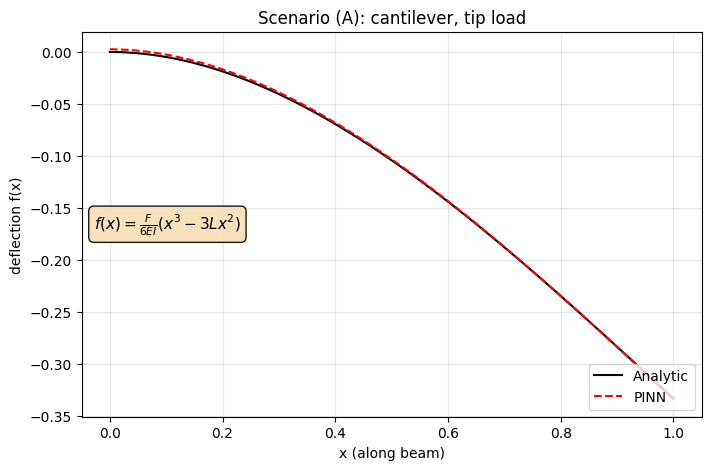

Saved: C:\Users\mpave\OneDrive - Massachusetts Institute of Technology\2.174 Mechanics and Materials via Machine Learning\PS3\charts\1b_A.png
Boundary condition residuals (A):
  disp_0 = [0.00264832]
  slope_0 = [-0.00350296]
  moment_L = [0.00070152]
  shear_L_minus_F = [0.0004909]


In [27]:
# Scenario (A): PINN vs analytic, save under charts/
plot_pinn_vs_analytic(
    "Scenario (A): cantilever, tip load",
    f_analytic_A,
    "1b_A.png",
    invert_yaxis=False,
    analytic_eq=r"$f(x)=\frac{F}{6EI}\left(x^3-3Lx^2\right)$",
)
bc = bc_terms_case_A()
print("Boundary condition residuals (A):")
for name in bc:
    print(" ", name, "=", bc[name].numpy().reshape(-1))


#### PINN for (B)


In [28]:
# Scenario (B): cantilever, uniform load — f'''' = w (EI=1 → Q_load = W)
Q_load.assign(W)
model = make_model()
train_pinn(bc_terms_case_B)


step: 0   total: 0.9192548394203186   pde: 0.8905531167984009   bc: 0.02870173752307892
step: 200   total: 0.010778025723993778   pde: 0.007890240289270878   bc: 0.0028877852018922567
step: 400   total: 0.003791723633185029   pde: 0.0035913418978452682   bc: 0.00020038180809933692
step: 600   total: 0.0014039934612810612   pde: 0.001376178814098239   bc: 2.7814596251118928e-05
step: 800   total: 0.0002729548723436892   pde: 0.00026216867263428867   bc: 1.0786190614453517e-05
step: 1000   total: 0.002659483114257455   pde: 0.0023300901520997286   bc: 0.00032939304946921766
step: 1200   total: 4.301139779272489e-05   pde: 4.289241405786015e-05   bc: 1.1898204377303045e-07
step: 1400   total: 3.572408968466334e-05   pde: 3.5642387956613675e-05   bc: 8.17003353859036e-08
step: 1600   total: 4.016822640551254e-05   pde: 3.827299224212766e-05   bc: 1.8952338223243714e-06
step: 1800   total: 2.5940960767911747e-05   pde: 2.5909892428899184e-05   bc: 3.1068552175383957e-08
step: 2000   total: 

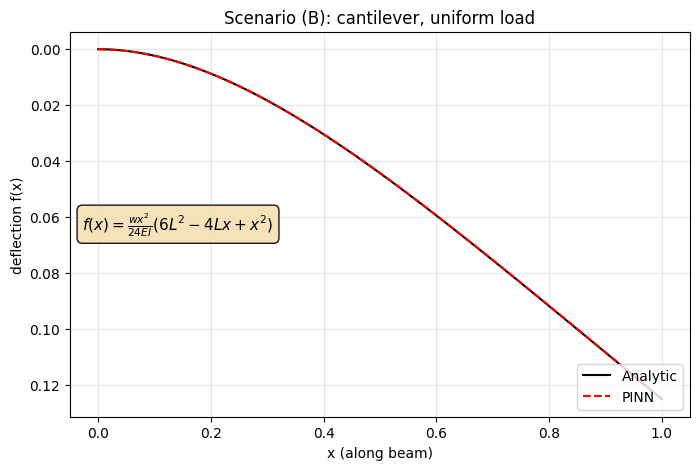

Saved: C:\Users\mpave\OneDrive - Massachusetts Institute of Technology\2.174 Mechanics and Materials via Machine Learning\PS3\charts\1b_B.png
Boundary condition residuals (B):
  disp_0 = [1.4081597e-06]
  slope_0 = [-1.6719103e-05]
  moment_L = [-6.247498e-05]
  shear_L = [-6.175041e-05]


In [29]:
plot_pinn_vs_analytic(
    "Scenario (B): cantilever, uniform load",
    f_analytic_B,
    "1b_B.png",
    analytic_eq=r"$f(x)=\frac{w x^2}{24EI}\left(6L^2-4Lx+x^2\right)$",
)
bc = bc_terms_case_B()
print("Boundary condition residuals (B):")
for name in bc:
    print(" ", name, "=", bc[name].numpy().reshape(-1))


#### PINN for (C)


In [30]:
# Scenario (C): simply supported, uniform load w (code: W). Part (a) deflection has y'''' = -w/EI with EI=1.
Q_load.assign(-W)
model = make_model()
train_pinn(bc_terms_case_C)


step: 0   total: 0.6595096588134766   pde: 0.3731371760368347   bc: 0.28637248277664185
step: 200   total: 0.007734040729701519   pde: 0.007118606474250555   bc: 0.000615434255450964
step: 400   total: 0.001987302675843239   pde: 0.0016208031447604299   bc: 0.00036649941466748714
step: 600   total: 0.0001814414863474667   pde: 0.00018008153710979968   bc: 1.3599491239801864e-06
step: 800   total: 2.5912826458807103e-05   pde: 2.5840341550065205e-05   bc: 7.248483768762526e-08
step: 1000   total: 0.001269413623958826   pde: 0.0011696802685037255   bc: 9.973331907531247e-05
step: 1200   total: 1.8288548744749278e-05   pde: 1.819831049942877e-05   bc: 9.023765557003571e-08
step: 1400   total: 9.940711606759578e-05   pde: 7.666280725970864e-05   bc: 2.274431062687654e-05
step: 1600   total: 1.5817762687220238e-05   pde: 1.568737206980586e-05   bc: 1.303909726857455e-07
step: 1800   total: 1.0710216884035617e-05   pde: 1.0623239177220967e-05   bc: 8.697791997747117e-08
step: 2000   total: 0

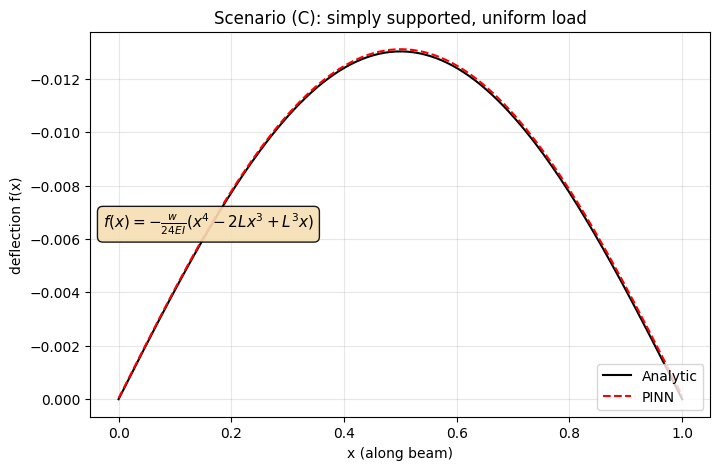

Saved: C:\Users\mpave\OneDrive - Massachusetts Institute of Technology\2.174 Mechanics and Materials via Machine Learning\PS3\charts\1b_C.png
Boundary condition residuals (C):
  disp_0 = [-3.837794e-05]
  disp_L = [-0.00012673]
  moment_0 = [6.5267086e-05]
  moment_L = [6.765872e-05]


In [31]:
plot_pinn_vs_analytic(
    "Scenario (C): simply supported, uniform load",
    f_analytic_C,
    "1b_C.png",
    analytic_eq=r"$f(x)=-\frac{w}{24EI}\left(x^4-2Lx^3+L^3x\right)$",
)
bc = bc_terms_case_C()
print("Boundary condition residuals (C):")
for name in bc:
    print(" ", name, "=", bc[name].numpy().reshape(-1))


### (C)

(i)

<img src="photos/1c.png" width="600" />

(ii)

<img src="photos/1c_ii.png" width="600" />

## Problem 2

Graph neural network for spider web **strength** and **toughness** (WebNet data).


### (a) Convolutional GNN (GCN)

Adapted from the course `WebNet_GNN` notebook: **PyTorch Geometric** builds one `Data` object per web (node features = **x,y,z** coordinates; edges from **bond** tables; label = **AverageStrength** or **AverageToughness**). The last code cell trains **two separate models** (Strength, then Toughness). Data live under `data/WebNet_Mar6/` next to this notebook.

If imports fail in a fresh environment, install (CPU PyTorch example):

`pip install torch --index-url https://download.pytorch.org/whl/cpu` then `pip install torch-geometric scikit-learn pandas tqdm matplotlib`.


In [4]:
# --- Problem 2(a): imports, paths, device ---
import os
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from torch.nn import Linear
from torch.optim.lr_scheduler import ReduceLROnPlateau
from sklearn.model_selection import train_test_split
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GCNConv, global_mean_pool

from tqdm.auto import tqdm


def homework_dir() -> Path:
    """Folder that contains PS3.ipynb (works if cwd is elsewhere)."""
    cwd = Path(".").resolve()
    for p in [cwd] + list(cwd.parents):
        if (p / "PS3.ipynb").is_file():
            return p
    return cwd


ROOT = homework_dir()
MANIFEST_CSV = ROOT / "data" / "WebNet_Mar6" / "fullmix.csv"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("ROOT:", ROOT.resolve())
print("Manifest:", MANIFEST_CSV.resolve(), "exists:", MANIFEST_CSV.is_file())
print("Device:", device, "| torch:", torch.__version__)


ROOT: C:\Users\mpave\OneDrive - Massachusetts Institute of Technology\2.174 Mechanics and Materials via Machine Learning\PS3
Manifest: C:\Users\mpave\OneDrive - Massachusetts Institute of Technology\2.174 Mechanics and Materials via Machine Learning\PS3\data\WebNet_Mar6\fullmix.csv exists: True
Device: cpu | torch: 2.11.0+cpu


In [5]:
# --- Build PyG Data list from manifest (same logic as WebNet_GNN.ipynb) ---


def graph_folder(rel_dir: str) -> Path:
    """Turn CSV dir entry into absolute path under ROOT/data/..."""
    rel = rel_dir.replace("\\", "/").lstrip("./")
    return (ROOT / "data" / rel).resolve()


def build_data_list(pro_type: str):
    """pro_type: 'Strength' or 'Toughness'."""
    if pro_type not in ("Strength", "Toughness"):
        raise ValueError("pro_type must be 'Strength' or 'Toughness'")

    graph_label_raw = pd.read_csv(MANIFEST_CSV)
    filelist = graph_label_raw["dir"]
    if pro_type == "Strength":
        graph_label_list = graph_label_raw["AverageStrength"]
    else:
        graph_label_list = graph_label_raw["AverageToughness"]

    data_list = []
    for i in range(len(filelist)):
        folder = graph_folder(str(filelist.iloc[i]))
        try:
            node_raw = pd.read_csv(folder / "atomXYZ_final.csv")
            edge_raw = pd.read_csv(folder / "bond_final.csv")

            nx = np.array(node_raw["x"]).reshape(-1, 1)
            ny = np.array(node_raw["y"]).reshape(-1, 1)
            nz = np.array(node_raw["z"]).reshape(-1, 1)
            node_list = np.hstack((nx, ny, nz))

            n1 = np.array(edge_raw["node1"] - 1).reshape(-1, 1)
            n2 = np.array(edge_raw["node2"] - 1).reshape(-1, 1)
            a = np.hstack((n1, n2))
            b = np.hstack((n2, n1))
            ab = np.append(a, b, axis=0)
            edge_list = np.transpose(ab)

            graph_label = np.array(graph_label_list.iloc[i]).reshape(1, -1)

            x = torch.tensor(node_list, dtype=torch.float)
            edge_index = torch.tensor(edge_list, dtype=torch.long)
            y = torch.tensor(graph_label, dtype=torch.float)
            data_list.append(Data(x=x, edge_index=edge_index, y=y))
        except Exception as e:
            print(f"Skip index {i} ({folder}): {e}")

    return data_list


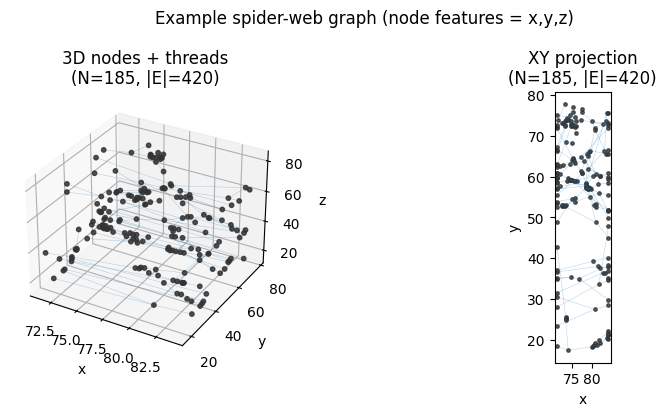

Saved: C:\Users\mpave\OneDrive - Massachusetts Institute of Technology\2.174 Mechanics and Materials via Machine Learning\PS3\charts\webnet_gnn\sample_web_primary.png


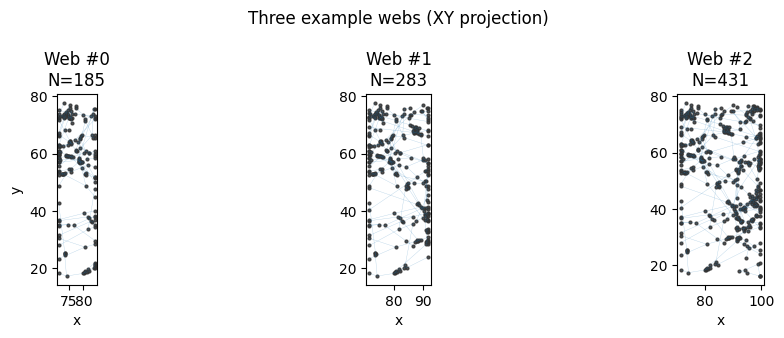

Saved: C:\Users\mpave\OneDrive - Massachusetts Institute of Technology\2.174 Mechanics and Materials via Machine Learning\PS3\charts\webnet_gnn\sample_web_triptych.png


In [6]:
# --- Visualize a few WebNet graphs (3D + XY projection) ---
# Run after `homework_dir` / `build_data_list` are defined above.

import matplotlib.pyplot as plt

# Load one target only for plotting (geometry is the same for Strength vs Toughness)
_viz_list = build_data_list("Strength")


def plot_single_web(ax3d, ax_xy, data, title_suffix=""):
    """Draw one graph: 3D nodes+edges and an XY top-down view."""
    pts = data.x.detach().cpu().numpy()
    ei = data.edge_index.detach().cpu().numpy()
    # Unique undirected edges for cleaner drawing (bond list is duplicated both ways)
    seen = set()
    edges = []
    for a, b in ei.T:
        u, v = int(a), int(b)
        if u == v:
            continue
        key = (u, v) if u < v else (v, u)
        if key in seen:
            continue
        seen.add(key)
        edges.append((u, v))

    # 3D
    ax3d.scatter(pts[:, 0], pts[:, 1], pts[:, 2], s=10, c="0.2", alpha=0.85, depthshade=True)
    for u, v in edges:
        ax3d.plot(
            [pts[u, 0], pts[v, 0]],
            [pts[u, 1], pts[v, 1]],
            [pts[u, 2], pts[v, 2]],
            color="C0",
            lw=0.35,
            alpha=0.35,
        )
    ax3d.set_xlabel("x")
    ax3d.set_ylabel("y")
    ax3d.set_zlabel("z")
    ax3d.set_title("3D nodes + threads" + title_suffix)

    # XY (top-down)
    ax_xy.scatter(pts[:, 0], pts[:, 1], s=6, c="0.2", alpha=0.8)
    for u, v in edges:
        ax_xy.plot(
            [pts[u, 0], pts[v, 0]],
            [pts[u, 1], pts[v, 1]],
            color="C0",
            lw=0.35,
            alpha=0.35,
        )
    ax_xy.set_aspect("equal", adjustable="box")
    ax_xy.set_xlabel("x")
    ax_xy.set_ylabel("y")
    ax_xy.set_title("XY projection" + title_suffix)


# Figure 1 — first graph in detail
if _viz_list:
    d0 = _viz_list[0]
    fig = plt.figure(figsize=(10, 4.2))
    ax3d = fig.add_subplot(1, 2, 1, projection="3d")
    ax_xy = fig.add_subplot(1, 2, 2)
    plot_single_web(
        ax3d,
        ax_xy,
        d0,
        title_suffix=f"\n(N={d0.num_nodes}, |E|={d0.edge_index.shape[1]})",
    )
    fig.suptitle("Example spider-web graph (node features = x,y,z)", fontsize=12)
    plt.tight_layout()
    out1 = ROOT / "charts" / "webnet_gnn" / "sample_web_primary.png"
    out1.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(out1, dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved:", out1.resolve())

# Figure 2 — three different webs, XY only (quick visual scan)
fig2, axes = plt.subplots(1, 3, figsize=(11, 3.4), sharex=False, sharey=False)
for j, ax in enumerate(axes.ravel()):
    if j >= len(_viz_list):
        ax.axis("off")
        continue
    dj = _viz_list[j]
    pts = dj.x.detach().cpu().numpy()
    ei = dj.edge_index.detach().cpu().numpy()
    seen = set()
    edges = []
    for a, b in ei.T:
        u, v = int(a), int(b)
        if u == v:
            continue
        key = (u, v) if u < v else (v, u)
        if key in seen:
            continue
        seen.add(key)
        edges.append((u, v))
    ax.scatter(pts[:, 0], pts[:, 1], s=4, c="0.2", alpha=0.85)
    for u, v in edges:
        ax.plot(
            [pts[u, 0], pts[v, 0]],
            [pts[u, 1], pts[v, 1]],
            color="C0",
            lw=0.25,
            alpha=0.35,
        )
    ax.set_aspect("equal", adjustable="box")
    ax.set_title(f"Web #{j}\nN={dj.num_nodes}")
    ax.set_xlabel("x")
    if j == 0:
        ax.set_ylabel("y")
fig2.suptitle("Three example webs (XY projection)", fontsize=12)
plt.tight_layout()
out2 = ROOT / "charts" / "webnet_gnn" / "sample_web_triptych.png"
out2.parent.mkdir(parents=True, exist_ok=True)
fig2.savefig(out2, dpi=150, bbox_inches="tight")
plt.show()
print("Saved:", out2.resolve())


In [7]:
# --- GCN regression model (graph-level mean pool + linear head) ---


class GCN(torch.nn.Module):
    def __init__(self, in_channels: int, hidden_channels: int, out_channels: int = 1):
        super().__init__()
        torch.manual_seed(42)
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels)
        self.conv3 = GCNConv(hidden_channels, hidden_channels)
        self.lin = Linear(hidden_channels, out_channels)

    def forward(self, x, edge_index, batch):
        x = x.to(self.lin.weight.device)
        edge_index = edge_index.to(self.lin.weight.device)
        batch = batch.to(self.lin.weight.device)
        x = self.conv1(x, edge_index).relu()
        x = self.conv2(x, edge_index).relu()
        x = self.conv3(x, edge_index)
        x = global_mean_pool(x, batch)
        x = F.dropout(x, p=0.2, training=self.training)
        return self.lin(x)


In [14]:
# --- Train / validate / test + save curves (per target) ---


def run_training(
    pro_type: str,
    *,
    hidden_channels: int = 32,
    batch_size: int = 32,
    epochs: int = 30,
    lr: float = 0.002,
    random_state: int = 47,
):
    data_list = build_data_list(pro_type)
    if not data_list:
        raise RuntimeError("No graphs loaded; check manifest paths under data/WebNet_Mar6.")

    in_ch = int(data_list[0].num_node_features)

    Train_data, Test_data = train_test_split(data_list, test_size=0.4, random_state=random_state)
    Test_data, Val_data = train_test_split(Test_data, test_size=0.5, random_state=random_state)

    train_loader = DataLoader(Train_data, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(Val_data, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(Test_data, batch_size=batch_size, shuffle=False)

    print(
        f"[{pro_type}] train={len(Train_data)} val={len(Val_data)} test={len(Test_data)} "
        f"| in_features={in_ch}"
    )

    out_root = ROOT / "charts" / "webnet_gnn" / "GCN" / pro_type
    best_dir = out_root / "best_model"
    plot_dir = out_root / "plots"
    for d in (best_dir, plot_dir):
        d.mkdir(parents=True, exist_ok=True)

    model = GCN(in_ch, hidden_channels, 1).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=12, min_lr=1e-5)
    mae = torch.nn.L1Loss()

    def train_epoch():
        model.train()
        total, count = 0.0, 0
        for data in train_loader:
            data = data.to(device)
            optimizer.zero_grad()
            out = model(data.x, data.edge_index, data.batch)
            loss = mae(out.squeeze(), data.y.squeeze())
            loss.backward()
            total += float(loss.item()) * data.num_graphs
            count += data.num_graphs
            optimizer.step()
        return total / max(count, 1)

    @torch.no_grad()
    def eval_mae(loader):
        model.eval()
        total, count = 0.0, 0
        for data in loader:
            data = data.to(device)
            out = model(data.x, data.edge_index, data.batch)
            loss = mae(out.squeeze(), data.y.squeeze())
            total += float(loss.item()) * data.num_graphs
            count += data.num_graphs
        return total / max(count, 1)

    train_maes, val_maes, test_maes = [], [], []
    best_val = float("inf")

    for epoch in tqdm(range(1, epochs + 1), desc=f"GCN / {pro_type}"):
        tr = train_epoch()
        va = eval_mae(val_loader)
        te = eval_mae(test_loader)
        train_maes.append(tr)
        val_maes.append(va)
        test_maes.append(te)
        scheduler.step(va)
        if va < best_val:
            best_val = va
            torch.save(model.state_dict(), best_dir / "model.pt")

    import matplotlib.pyplot as plt

    xs = np.arange(1, epochs + 1)
    plt.figure(figsize=(7, 4))
    plt.plot(xs, train_maes, label="train MAE")
    plt.plot(xs, val_maes, label="val MAE")
    plt.plot(xs, test_maes, label="test MAE")
    plt.xlabel("epoch")
    plt.ylabel("MAE")
    plt.title(f"WebNet GCN — {pro_type}")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(plot_dir / "loss_curves.png", dpi=150)
    plt.show()

    print(f"[{pro_type}] best val MAE ≈ {best_val:.4f} | weights → {best_dir / 'model.pt'}")
    print(f"[{pro_type}] plot → {plot_dir / 'loss_curves.png'}")


[Strength] train=120 val=40 test=40 | in_features=3


GCN / Strength: 100%|██████████| 30/30 [00:24<00:00,  1.21it/s]


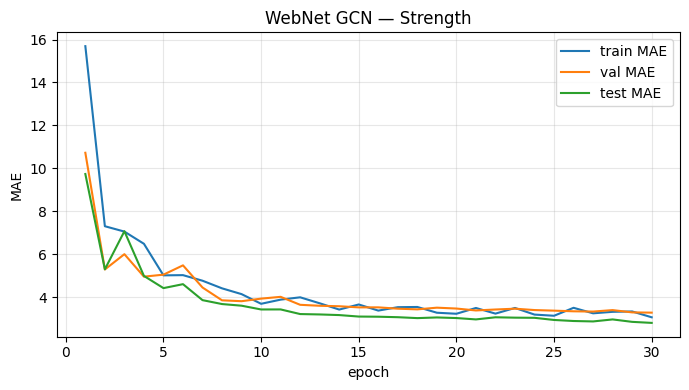

[Strength] best val MAE ≈ 3.2757 | weights → C:\Users\mpave\OneDrive - Massachusetts Institute of Technology\2.174 Mechanics and Materials via Machine Learning\PS3\charts\webnet_gnn\GCN\Strength\best_model\model.pt
[Strength] plot → C:\Users\mpave\OneDrive - Massachusetts Institute of Technology\2.174 Mechanics and Materials via Machine Learning\PS3\charts\webnet_gnn\GCN\Strength\plots\loss_curves.png
[Toughness] train=120 val=40 test=40 | in_features=3


GCN / Toughness: 100%|██████████| 30/30 [00:24<00:00,  1.22it/s]


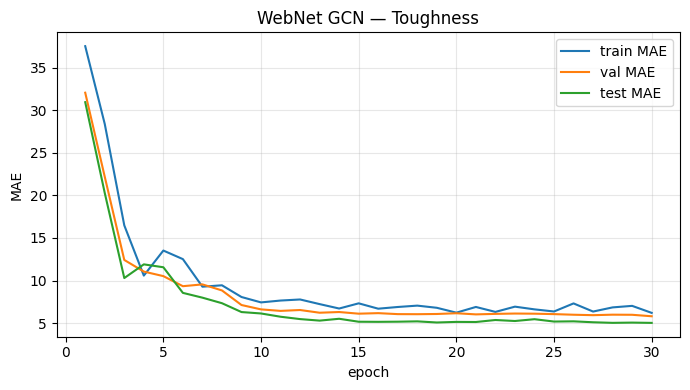

[Toughness] best val MAE ≈ 5.8137 | weights → C:\Users\mpave\OneDrive - Massachusetts Institute of Technology\2.174 Mechanics and Materials via Machine Learning\PS3\charts\webnet_gnn\GCN\Toughness\best_model\model.pt
[Toughness] plot → C:\Users\mpave\OneDrive - Massachusetts Institute of Technology\2.174 Mechanics and Materials via Machine Learning\PS3\charts\webnet_gnn\GCN\Toughness\plots\loss_curves.png


In [15]:
# --- Part (a): train two separate GCN models (strength, then toughness) ---
# Lower `epochs` while debugging; increase for final submission.

run_training("Strength", epochs=30)
run_training("Toughness", epochs=30)
